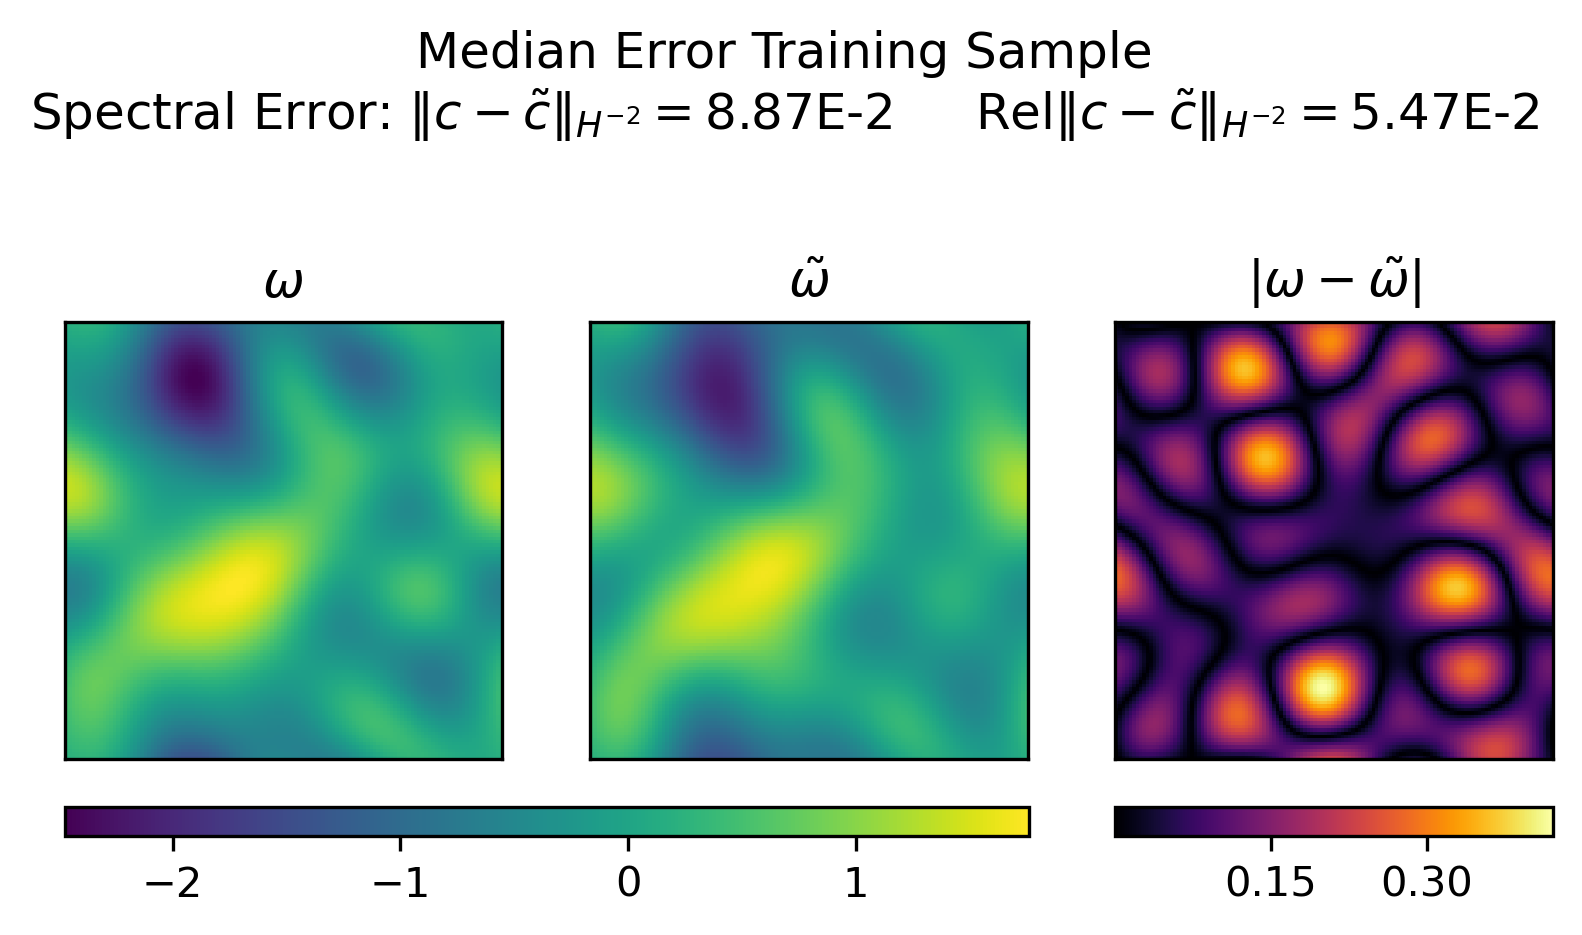

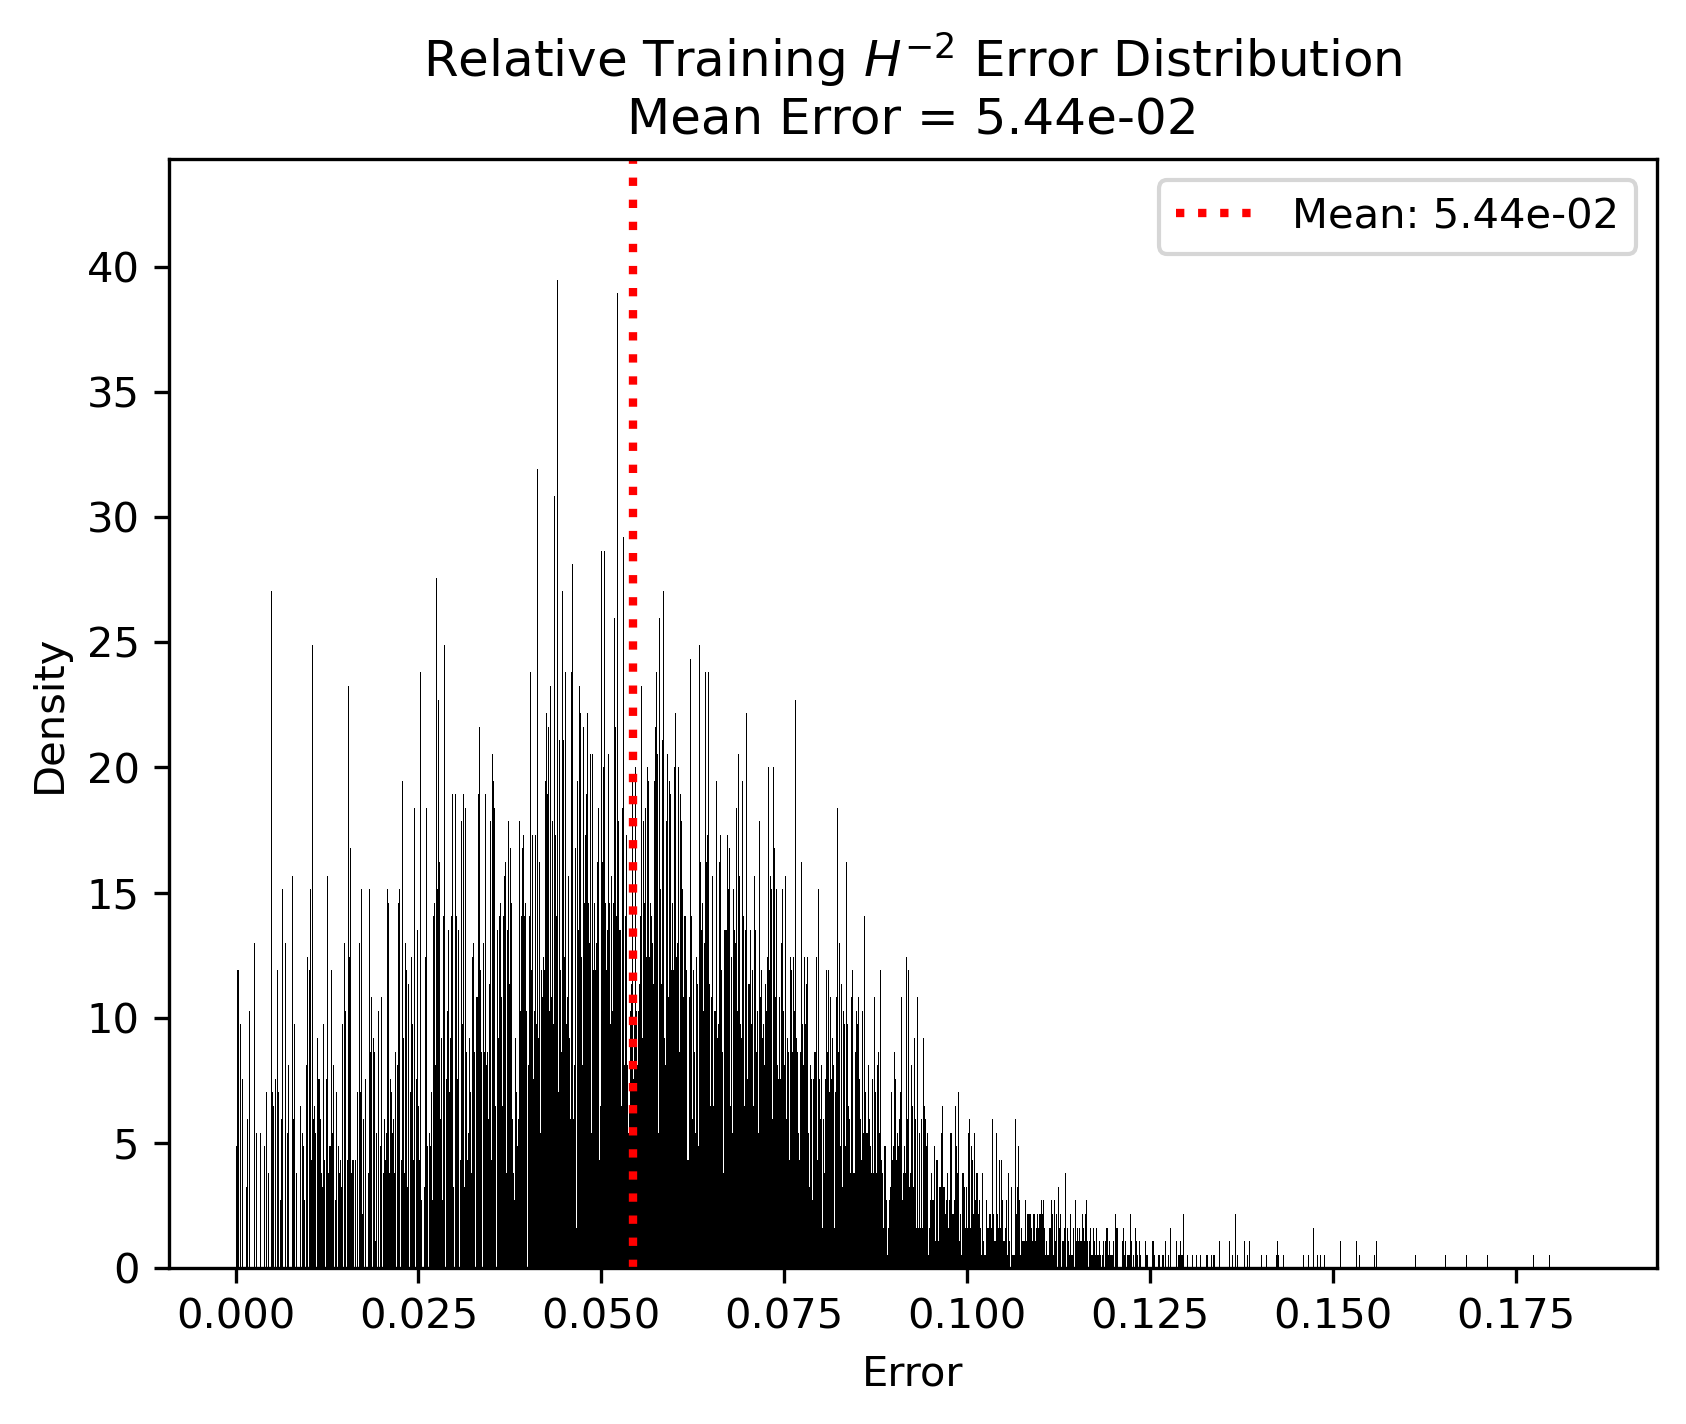

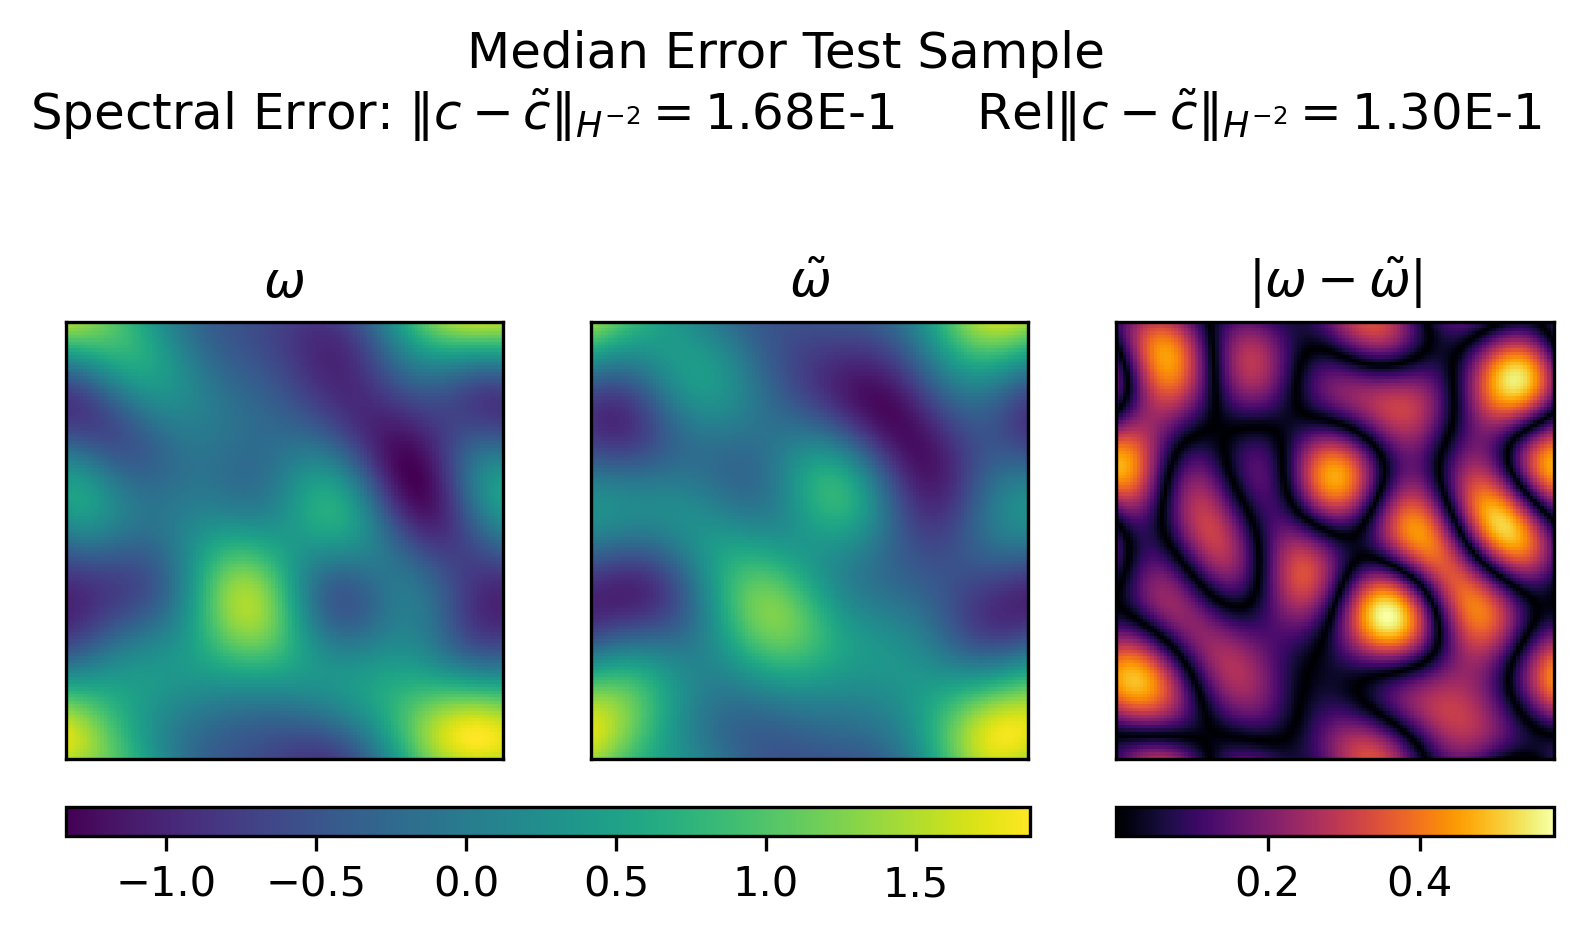

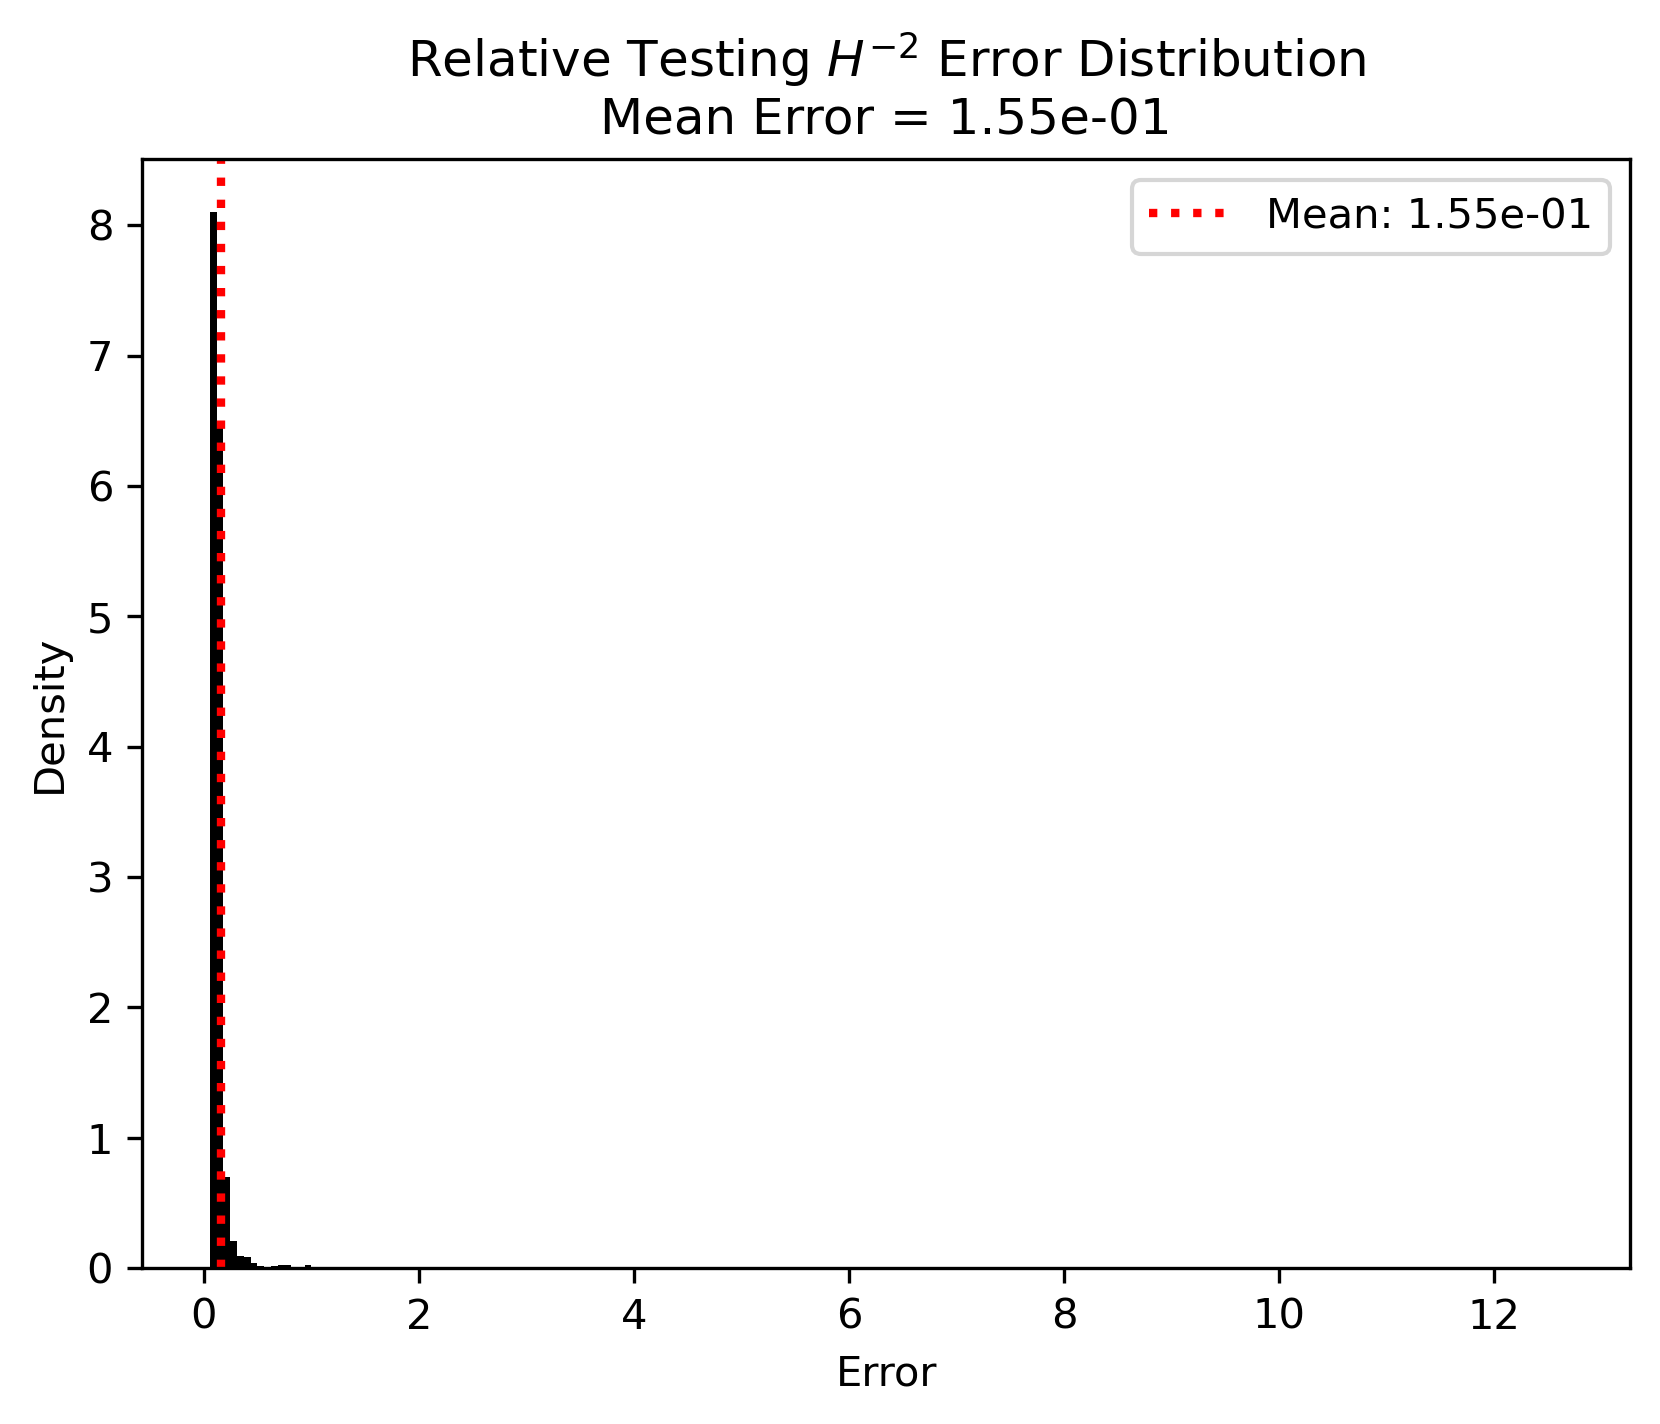

In [1]:
################################################################################################################
################################################################################################################
###                       Orthogonal Polynomial Operator Learning with Induced Sampling:
###                                Learn the NS Solution Operator from Data                                       
################################################################################################################
################################################################################################################

################################################################################################################
###                                             Import libraries:
################################################################################################################
import sys
sys.path.insert(0, '../Modules/')

import numpy as np
import torch
from sklearn.decomposition import PCA
from index_set import index_set
#from index_set import bounded_hyperbolic_cross_set
from families import JacobiPolynomials
from HAlphaBasisCompressor import HAlphaBasisCompressor
from OperatorLearningPlotter import OperatorLearningPlotter
from Empirical_Operator_WLS import Empirical_Operator_WLS

################################################################################################################
#                                                 Parameters   
################################################################################################################

### Dimension Reduction parameters
nPCA_Max =  750              # Maximum number of PCA modes allowed
PCA_Threshold = 0.995        # Amount of energy to retain in input space
alpha = -2                    # Sobolev Parameter for output space: 0 = L^2, 1 = H^1, etc.  
HAlpha_Threshold = 0.999     # Amount of energy to retain in output data

### Index set params
HC_Param = 28                # Hyperbolic Cross Parameter ~ set large to reach max size
max_poly_indx = 10           # Maximum degree of (univariate) polynomial in gPC
N_max = 50000                # Maximum size of (effective) hyperbolic index set
anisotropic = True           # Weight poly-deg multi-indices by normalized sing val of input dat    

### Scale input data to lie in [-1,1]: 
normalization = 'uniform'    # Scale all input data uniformly, to maintain relative magnitudes
#normalization = 'entrywise' # Scale each mode of input data separately 

### Log:
Log = False                  # Print Condition Numbers, Errors, Parameters, etc. 

################################################################################################################
#                                      Load, Reshape, & Reduce Data
################################################################################################################

### Load data 
# Spatial data is on 128 x 128 grid
train_dat = torch.load('Spatial_Data/nsforcing_train_128.pt', weights_only=True)
test_dat  = torch.load('Spatial_Data/nsforcing_test_128.pt', weights_only=True )
X_train_grid = train_dat['x'].numpy()
Y_train_grid = train_dat['y'].numpy()
X_test_grid  = test_dat['x'].numpy()
Y_test_grid  = test_dat['y'].numpy()

# Reshape X grid data to vector for PCA
X_train = X_train_grid.reshape(X_train_grid.shape[0],-1)
X_test  = X_test_grid.reshape(X_test_grid.shape[0], -1) 

# Adaptively choose number of PCA coeffcients 
pca = PCA(n_components = nPCA_Max)
pca.fit(X_train)
nPCA_X = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), PCA_Threshold)+1

# Preform PCA to lower dimensionality
pca_X = PCA(n_components=nPCA_X)
input_data_raw = pca_X.fit_transform(X_train)
input_data_raw_test = pca_X.transform(X_test)

# Scale input coefficients to lie in [-1,1] for Jacobi Polynomial Domain 
if normalization == 'uniform':
    linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test))))
    input_data = input_data_raw / linf
    input_test = input_data_raw_test / linf

elif normalization == 'entrywise': 
    input_data = np.zeros_like(input_data_raw)
    input_test = np.zeros_like(input_data_raw_test)
    for col in range(nPCA_X):
        linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test)))[:,col])
        input_data[:,col] = input_data_raw[:,col]/linf
        input_test[:,col] = input_data_raw_test[:,col]/linf
else:
    raise ValueError("Normalization must be either 'uniform' for 'entrywise'")

# Project Y Data onto H^alpha subspace:
compressor = HAlphaBasisCompressor(N=Y_train_grid.shape[1], threshold=HAlpha_Threshold, alpha = alpha)
compressor.fit(Y_train_grid) 
output_data = np.array([compressor.project(snapshot) for snapshot in Y_train_grid])
output_test = np.array([compressor.project(snapshot) for snapshot in Y_test_grid])

### Fit Jacobi Parameters Defining Measure on Input Space by Matching Empirical Variance 
#   NOTE: For symmetric beta distribution, Var_a = 1/(2a + 3)
VarX = np.var(input_data, axis = 0)
VarX_safe = np.clip(VarX, 1e-10, None)  # avoid blow up for near zero variance
jParams = ((1/VarX) - 3)/2   

################################################################################################################
#                                               Define Index Set
################################################################################################################

# Define index set weights
idx_weights = pca_X.singular_values_ / pca_X.singular_values_[0] if anisotropic else np.ones(nPCA_X)

# Define polynomial part of index set
PolyIdxs = index_set(d = nPCA_X, param = HC_Param, max_index = max_poly_indx, weights = idx_weights, max_size = N_max, type = 'hc' )
#PolyIdxs = bounded_hyperbolic_cross_set(nPCA_X, HC_Param, max_poly_indx, idx_weights, N_max)
N = PolyIdxs.shape[0]
M = int(N*np.log(N))
################################################################################################################
###                                           Operator Learning 
################################################################################################################

# Init Operator Learning Class 
wls_operator = Empirical_Operator_WLS(
    input_data = input_data, 
    output_data = output_data, 
    index_set = PolyIdxs, 
    jacobi_params = jParams)

# Fit Operator to Training Data 
wls_operator.fit(M)

# Evaluate Operator on Training Data
ApproxOpSamp = wls_operator.predict_on_fit_samples()
err, rel_err = wls_operator.compute_fit_sample_errors()

# Evaluate Operator on Testing Data
ApproxOpTest = wls_operator.predict(input_test)
test_err, rel_test_err = wls_operator.compute_errors(input_test, output_test)

################################################################################################################
###                                               Error Plots
################################################################################################################
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
### Plots for Training Data 
train_plotter = OperatorLearningPlotter(
        domain = (0, 2 * np.pi, 0, 2 * np.pi),
        alpha = alpha,
        color_map = 'viridis',
        err_color_map = 'inferno',
)
sample = np.argmin(np.abs(err - np.median(err)))

# Move Data Back to Spatial Domain
approx_vorticity = compressor.reconstruct_spatial(ApproxOpSamp[sample])
true_vorticity = compressor.reconstruct_spatial(output_data[wls_operator.opt_samples[sample]])

# Plot Reconstructed Comparison and Error Distribution 
train_plotter.plot_comparison(
    true_field=true_vorticity,
    approx_field=approx_vorticity,
    spectral_error=err[sample],
    spatial_error=np.linalg.norm(true_vorticity - approx_vorticity),
    rel_spectral_error= err[sample] / np.linalg.norm(output_data[wls_operator.opt_samples[sample]]),
    rel_spatial_error=np.linalg.norm(true_vorticity - approx_vorticity) / np.linalg.norm(true_vorticity),
    title_prefix="Median Error Training Sample"
)
# Plot Relative Error Distribution 
train_plotter.plot_error_distribution(rel_err, title_prefix="Relative Training")

### Plots for Testing Data 
test_plotter = OperatorLearningPlotter(
        domain = (0, 2 * np.pi, 0, 2 * np.pi),
        alpha = alpha,
        color_map = 'viridis',
        err_color_map = 'inferno',
)
sample = np.argmin(np.abs(test_err - np.median(test_err)))

# Move Data Back to Spatial Domain
approx_vorticity = compressor.reconstruct_spatial(ApproxOpTest[sample])
true_vorticity = compressor.reconstruct_spatial(output_test[sample])

# Plot Reconstructed Comparison and Error Distribution 
test_plotter.plot_comparison(
    true_field=true_vorticity,
    approx_field=approx_vorticity,
    spectral_error=test_err[sample],
    spatial_error=np.linalg.norm(true_vorticity - approx_vorticity),
    rel_spectral_error= test_err[sample] / np.linalg.norm(output_test[sample]),
    rel_spatial_error=np.linalg.norm(true_vorticity - approx_vorticity) / np.linalg.norm(true_vorticity),
    title_prefix="Median Error Test Sample"
)
# Plot Relative Test Error Distribution 
test_plotter.plot_error_distribution(rel_test_err, title_prefix="Relative Testing")

################################################################################################################
###                                             Print Log
################################################################################################################
if Log: 
    print("+------------------------------------------+")
    print("       General Optimization Parameters ")
    print("+------------------------------------------+")
    print(f"Dimension of Input Space:              {nPCA_X}")
    print(f"Number of Input Samples:               {M}")
    print(f"Dimension of Output Space:             {compressor.M}")
    print(f"Effective Dimension of Operator Space: {N} ")
    print(f"Anisotropic Index Set:                 {anisotropic}")
    print("+------------------------------------------+")
    print("        Stability of the WLS Problem ")
    print("+------------------------------------------+")
    print("+------------Training Matrices:")
    print(f"Vandermond: Cond(V) = {np.linalg.cond(wls_operator.V):.3e}" )
    print(f"QR:         Cond(Q) = {np.linalg.cond(wls_operator.Q):.3e}")
    print(f"            Cond(R) = {np.linalg.cond(wls_operator.R):.3e}" )
    print(f"Grammian:   Cond(G) = {np.linalg.cond(wls_operator.G):.3e}")
    print("+------------Testing Matrices:")
    print(f"Vandermond: Cond(V) = {np.linalg.cond(wls_operator.V_pred):.3e}" )
    print(f"Projection: Cond(Q) = {np.linalg.cond(wls_operator.Q_pred):.3e}" )
    print("+------------------------------------------+")
    print("                 Error")
    print("+------------------------------------------+")
    print(f"Mean Output Error on Training Data: {np.mean(err):.3e}")
    print(f"                          Relative: {np.mean(rel_err):.3e}")
    print(f"Mean Output Error on Testing Data:  {np.mean(test_err):.3e}")
    print(f"                          Relative: {np.mean(rel_test_err):.3e}")
    print("+------------------------------------------+")